# Binocular Rivalry VR Experiment: 1-to-1 Task & Proposition Analysis

This notebook analyzes the 4 experimental tasks, with each task specifically designed to evaluate one of the modernized **Levelt Propositions** (Brascamp, Klink, & Levelt, 2015):

| Task | Modality | Target Proposition | Core Metric |
|   :---     | :--- | :--- | :--- |
| **Task 1** | Holding (Unilateral) | **Proposition I**: Increasing stimulus strength increases predominance | **Predominance / Dominance %** |
| **Task 2** | Holding (Unilateral) | **Proposition II**: Increasing interocular difference increases duration of stronger stimulus | **Mean Dominance Duration** |
| **Task 3** | Tapping (Unilateral) | **Proposition III**: Increasing interocular difference reduces alternation rate | **Alternation Rate vs. Difference** |
| **Task 4** | Tapping (Bilateral) | **Proposition IV**: Bilateral strength increase generally increases alternation rate | **Alternation Rate vs. Bilateral Contrast** |

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure analyzer module can be imported regardless of execution working directory
cwd = Path.cwd()
for p in [cwd, cwd / "Analysis", cwd.parent / "Analysis"]:
    if (p / "analyzer.py").is_file() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import analyzer

# Configure visual styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

print("Analyzer module loaded successfully!")

Analyzer module loaded successfully!


## 1. Data Ingestion

Loads all `participant_{id}_task_{task}.json` files from the project-level `Data/` directory.

In [2]:
data_dir = analyzer.get_data_dir()
print(f"Using data directory: {data_dir}")

raw_trials = analyzer.load_all_trials(data_dir)
print(f"Total trials loaded: {len(raw_trials)}")

if len(raw_trials) == 0:
    print("Warning: No trial JSON files found in data_dir. Check that participant_*.json files exist in:", data_dir)
else:
    df = analyzer.build_summary_dataframe(raw_trials)
    print("\nTasks detected in dataset:", sorted(df["taskType"].unique().tolist()))
    display(df.head(10))

Using data directory: /mnt/d/Unity/vr-perceptual-experiment/Data
  - Loaded 3 trial(s) from participant_1_task_1.json
  - Loaded 3 trial(s) from trial_results.json
Total trials loaded: 6

Tasks detected in dataset: [1]


,participantID,taskType,trialNumber,isControl,contrastL,contrastR,variableEye,contrastVariable,contrastFixed,contrastDifference,...,predominanceWeaker,meanDurationLeftMs,meanDurationRightMs,meanDurationPiecemealMs,meanDurationVariableMs,meanDurationFixedMs,meanDurationStrongerMs,meanDurationWeakerMs,switchCount,switchRatePerMin
0,1,1,1,False,0.5,0.5,equal,0.5,0.5,0.0,...,12.917135,579.493400,712.220085,0.000000,645.856742,645.856742,645.856742,645.856742,4,24.0
1,1,1,2,False,0.5,0.9,right,0.9,0.5,0.4,...,5.226975,522.697540,423.122690,877.310000,423.122690,522.697540,423.122690,522.697540,7,42.0
2,1,1,3,True,0.5,0.9,right,0.9,0.5,0.4,...,0.000000,0.000000,0.000000,303.706700,0.000000,0.000000,0.000000,0.000000,5,30.0
3,0,1,1,False,0.1,0.5,left,0.1,0.5,0.4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4,24.0
4,0,1,2,False,0.7,0.5,left,0.7,0.5,0.2,...,0.000000,0.000000,0.000000,1.024385,0.000000,0.000000,0.000000,0.000000,3,18.0
5,0,1,3,False,0.5,0.3,right,0.3,0.5,0.2,...,0.000000,0.566883,0.000000,0.102684,0.000000,0.566883,0.566883,0.000000,13,78.0


## 2. Sample Trial Timeline (Perceptual Raster Plot)

Visualizes the temporal sequence of dominance intervals, transitions, and piecemeal states for an individual trial.

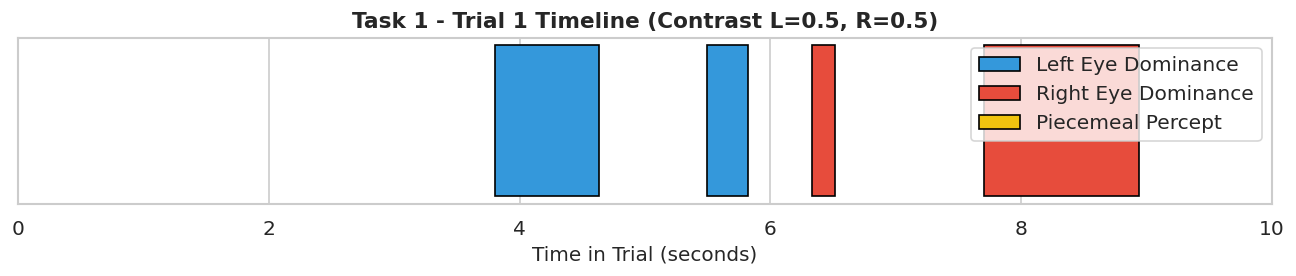

In [3]:
def plot_trial_timeline(trial_dict, title=None):
    episodes = analyzer.extract_trial_episodes(trial_dict)
    total_duration_ms = trial_dict.get("spec", {}).get("totalTrialMs", 10000.0)
    if episodes:
        total_duration_ms = max(total_duration_ms, max(e["end_ms"] for e in episodes))
        
    color_map = {
        "left": "#3498db",       # Blue for Left Eye
        "right": "#e74c3c",      # Red for Right Eye
        "piecemeal": "#f1c40f",  # Yellow for Piecemeal
        "none": "#abe0a9",       # Gray for none
        "unknown": "#838383"
    }
    
    fig, ax = plt.subplots(figsize=(11, 2.5))
    for ep in episodes:
        dom = ep["dominance"]
        ax.barh(0, ep["duration_ms"] / 1000.0, left=ep["start_ms"] / 1000.0,
                color=color_map.get(dom, "#838383"), edgecolor="black", height=0.6)
                
    ax.set_xlim(0, total_duration_ms / 1000.0)
    ax.set_yticks([])
    ax.set_xlabel("Time in Trial (seconds)", fontsize=12)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#3498db", edgecolor="black", label="Left Eye Dominance"),
        Patch(facecolor="#e74c3c", edgecolor="black", label="Right Eye Dominance"),
        Patch(facecolor="#f1c40f", edgecolor="black", label="Piecemeal Percept"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True)
    
    task_type = trial_dict.get("taskType", 1)
    trial_num = trial_dict.get("trialNumber", 1)
    cL = trial_dict.get("spec", {}).get("contrastL", 0.5)
    cR = trial_dict.get("spec", {}).get("contrastR", 0.5)
    plot_title = title or f"Task {task_type} - Trial {trial_num} Timeline (Contrast L={cL}, R={cR})"
    ax.set_title(plot_title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

if 'raw_trials' in locals() and len(raw_trials) > 0:
    plot_trial_timeline(raw_trials[0])

## 3. Task 1 $\rightarrow$ Proposition I: Stimulus Strength & Predominance

> **Proposition I**:
> *Increasing stimulus strength for one eye will increase the perceptual predominance of that eye’s stimulus.*

Evaluated using **Task 1** (Continuous Holding, Unilateral contrast manipulation).
Predominance is calculated as: $\left(\frac{\sum \text{Dominance Time}}{\text{Total Trial Duration}}\right) \times 100$.

Task 1: Predominance vs. Variable Eye Contrast:


,contrastVariable,predominanceVariable,predominanceFixed,dominancePctPiecemeal
0,0.1,0.000000,0.000000,0.000000
1,0.3,0.000000,0.011338,0.001027
2,0.5,11.589868,14.244402,0.000000
3,0.7,0.000000,0.000000,0.020488
4,0.9,6.346840,2.613488,7.423617


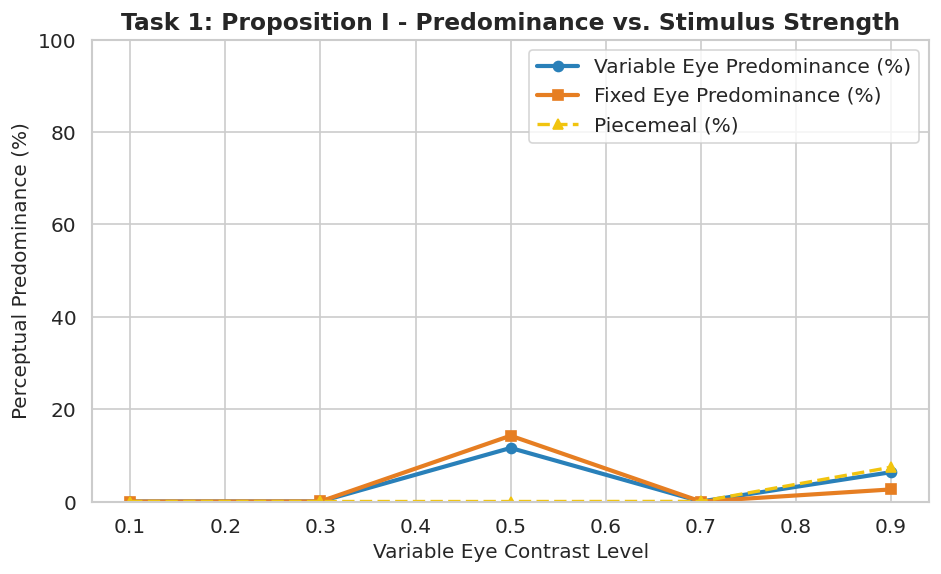

In [4]:
if 'df' in locals() and not df.empty:
    t1_df = df[df["taskType"] == 1]
    if not t1_df.empty:
        summary_p1 = t1_df.groupby("contrastVariable")[["predominanceVariable", "predominanceFixed", "dominancePctPiecemeal"]].mean().reset_index()
        print("Task 1: Predominance vs. Variable Eye Contrast:")
        display(summary_p1)

        plt.figure(figsize=(9, 5))
        plt.plot(summary_p1["contrastVariable"], summary_p1["predominanceVariable"], marker="o", color="#2980b9", lw=2.5, label="Variable Eye Predominance (%)")
        plt.plot(summary_p1["contrastVariable"], summary_p1["predominanceFixed"], marker="s", color="#e67e22", lw=2.5, label="Fixed Eye Predominance (%)")
        plt.plot(summary_p1["contrastVariable"], summary_p1["dominancePctPiecemeal"], marker="^", color="#f1c40f", lw=2, linestyle="--", label="Piecemeal (%)")
        plt.title("Task 1: Proposition I - Predominance vs. Stimulus Strength", fontsize=14, fontweight="bold")
        plt.xlabel("Variable Eye Contrast Level", fontsize=12)
        plt.ylabel("Perceptual Predominance (%)", fontsize=12)
        plt.ylim(0, 100)
        plt.legend()
        plt.show()
    else:
        print("No Task 1 data loaded yet. Run Task 1 in Unity to populate this section.")

## 4. Task 2 $\rightarrow$ Proposition II: Contrast Difference & Dominance Duration of the Stronger Stimulus

> **Proposition II**:
> *Increasing the difference in stimulus strength between the two eyes will primarily act to increase the average perceptual dominance duration of the stronger stimulus.*

Evaluated using **Task 2** (Continuous Holding, tracking individual episode durations across contrast differences $\Delta C = |C_L - C_R|$).

In [5]:
if 'df' in locals() and not df.empty:
    t2_df = df[df["taskType"] == 2]
    if not t2_df.empty:
        summary_p2 = t2_df.groupby("contrastDifference")[["meanDurationStrongerMs", "meanDurationWeakerMs"]].mean().reset_index()
        print("Task 2: Mean Dominance Durations across Interocular Difference |CL - CR|:")
        display(summary_p2)
        
        plt.figure(figsize=(9, 5))
        plt.plot(summary_p2["contrastDifference"], summary_p2["meanDurationStrongerMs"] / 1000.0, marker="o", lw=2.5, color="#27ae60", label="Stronger Stimulus Mean Duration (s)")
        plt.plot(summary_p2["contrastDifference"], summary_p2["meanDurationWeakerMs"] / 1000.0, marker="s", lw=2.5, color="#c0392b", label="Weaker Stimulus Mean Duration (s)")
        plt.title("Task 2: Proposition II - Dominance Duration vs. Interocular Difference (|CL - CR|)", fontsize=14, fontweight="bold")
        plt.xlabel("Difference in Stimulus Strength (|CL - CR|)", fontsize=12)
        plt.ylabel("Average Perceptual Dominance Duration (seconds)", fontsize=12)
        plt.legend()
        plt.show()
    else:
        print("No Task 2 data loaded yet. Run Task 2 in Unity to populate this section.")

No Task 2 data loaded yet. Run Task 2 in Unity to populate this section.


## 5. Task 3 $\rightarrow$ Proposition III: Contrast Difference & Alternation Rate

> **Proposition III**:
> *Increasing the difference in stimulus strength between the two eyes will reduce the perceptual alternation rate.*

Evaluated using **Task 3** (Discrete Switch Tapping, Unilateral contrast manipulation).
Evaluates how alternation rate (switches / minute) responds to changes in contrast difference $\Delta C = |C_L - C_R|$.

In [6]:
if 'df' in locals() and not df.empty:
    t3_df = df[df["taskType"] == 3]
    if not t3_df.empty:
        summary_p3 = t3_df.groupby("contrastDifference")["switchRatePerMin"].mean().reset_index()
        print("Task 3: Alternation Rate across Interocular Difference |CL - CR|:")
        display(summary_p3)
        
        plt.figure(figsize=(9, 5))
        plt.plot(summary_p3["contrastDifference"], summary_p3["switchRatePerMin"], marker="o", color="#8e44ad", lw=2.5, label="Alternation Rate (switches/min)")
        plt.title("Task 3: Proposition III - Alternation Rate vs. Interocular Difference (|CL - CR|)", fontsize=14, fontweight="bold")
        plt.xlabel("Difference in Stimulus Strength (|CL - CR|)", fontsize=12)
        plt.ylabel("Perceptual Alternation Rate (switches / min)", fontsize=12)
        plt.legend()
        plt.show()
    else:
        print("No Task 3 data loaded yet. Run Task 3 in Unity to populate this section.")

No Task 3 data loaded yet. Run Task 3 in Unity to populate this section.


## 6. Task 4 $\rightarrow$ Proposition IV: Bilateral Contrast & Alternation Rate

> **Proposition IV**:
> *Increasing stimulus strength in both eyes while keeping it equal between eyes will generally increase the perceptual alternation rate, but this effect may reverse at near-threshold stimulus strengths.*

Evaluated using **Task 4** (Discrete Switch Tapping, Bilateral contrast manipulation where $C_L = C_R$ across $0.1 \rightarrow 0.9$).

In [7]:
if 'df' in locals() and not df.empty:
    t4_df = df[df["taskType"] == 4]
    if not t4_df.empty:
        summary_p4 = t4_df.groupby("contrastL")["switchRatePerMin"].mean().reset_index()
        print("Task 4: Alternation Rate across Equal Bilateral Contrast:")
        display(summary_p4)
        
        plt.figure(figsize=(9, 5))
        plt.plot(summary_p4["contrastL"], summary_p4["switchRatePerMin"], marker="s", color="#d35400", lw=2.5, label="Equal Bilateral Contrast (CL = CR)")
        plt.title("Task 4: Proposition IV - Alternation Rate vs. Bilateral Stimulus Strength", fontsize=14, fontweight="bold")
        plt.xlabel("Bilateral Stimulus Contrast (CL = CR)", fontsize=12)
        plt.ylabel("Perceptual Alternation Rate (switches / min)", fontsize=12)
        plt.legend()
        plt.show()
    else:
        print("No Task 4 data loaded yet. Run Task 4 in Unity to populate this section.")

No Task 4 data loaded yet. Run Task 4 in Unity to populate this section.


## 7. Catch / Control Trials Analysis

In control trials (`isControl == True`), identical stimuli are presented to both eyes to verify participant attention and baseline response accuracy.

In [8]:
if 'df' in locals() and not df.empty:
    ctrl_summary = df.groupby("isControl")[["dominancePctTotal", "dominancePctPiecemeal", "switchCount"]].mean().reset_index()
    ctrl_summary["isControl"] = ctrl_summary["isControl"].map({True: "Control (Identical Stimuli)", False: "Rivalry (Divergent Stimuli)"})
    print("Comparison: Control vs. Rivalry Trials")
    display(ctrl_summary)

Comparison: Control vs. Rivalry Trials


,isControl,dominancePctTotal,dominancePctPiecemeal,switchCount
0,Rivalry (Divergent Stimuli),8.753253,1.758923,6.2
1,Control (Identical Stimuli),0.000000,6.074134,5.0


## 8. Export Consolidated Dataset

Export the computed metrics across all participants and trials to a clean CSV file (`perceptual_metrics_summary.csv`) for formal statistical analysis (e.g. repeated-measures ANOVA in SPSS, R, or Jamovi).

In [ ]:
if 'df' in locals() and not df.empty:
    output_csv = "perceptual_metrics_summary.csv"
    df.to_csv(output_csv, index=False)
    print(f"Dataset exported successfully to: {os.path.abspath(output_csv)}")
    print(f"Total trials: {len(df)}, Columns: {len(df.columns)}")